In [1]:
import os, sys, yaml, xml.etree.ElementTree as ET
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

In [2]:
cfg = yaml.safe_load(open('../configs/default.yaml'))
DATA_ROOT = Path(cfg['DATA_ROOT'])
CLASSES = cfg['CLASSES']
CLASS_COLORS = {'WBC': 'red', 'RBC': 'green', 'Platelets': 'blue'}

print(f"Data root: {DATA_ROOT.absolute()}")
print(f"Classes: {CLASSES}")

Data root: /Users/veronika_steklo/PycharmProjects/ML_NN_SSU/bccd/notebooks/../../data/BCCD_VOC/BCCD
Classes: ['WBC', 'RBC', 'Platelets']


In [3]:
def parse_voc_to_df(data_root: str) -> pd.DataFrame:
    ann_dir = Path(data_root) / 'Annotations'
    img_dir = Path(data_root) / 'JPEGImages'
    records = []

    for xml_path in ann_dir.glob('*.xml'):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        filename = root.find('filename').text
        size = root.find('size')
        w, h = int(size.find('width').text), int(size.find('height').text)

        counts = {cls: 0 for cls in CLASSES}
        boxes = []

        for obj in root.findall('object'):
            cls_name = obj.find('name').text
            if cls_name not in CLASSES: continue
            counts[cls_name] += 1
            bnd = obj.find('bndbox')
            x1, y1, x2, y2 = map(float, [bnd.find(t).text for t in ['xmin','ymin','xmax','ymax']])
            boxes.append({'class': cls_name, 'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2,
                          'w': x2-x1, 'h': y2-y1, 'area': (x2-x1)*(y2-y1)})

        records.append({'image_id': filename.replace('.jpg',''), 'path': str(img_dir/filename),
                        'img_w': w, 'img_h': h, **counts, 'total': sum(counts.values()), 'boxes': boxes})
    return pd.DataFrame(records)

df = parse_voc_to_df(DATA_ROOT)
print(f"✅ Загружено {len(df)} изображений")
df.head()

✅ Загружено 364 изображений


,image_id,path,img_w,img_h,WBC,RBC,Platelets,total,boxes
0,BloodImage_00315,../../data/BCCD_VOC/BCCD/JPEGImages/BloodImage...,640,480,1,10,1,12,"[{'class': 'RBC', 'x1': 164.0, 'y1': 261.0, 'x..."
1,BloodImage_00301,../../data/BCCD_VOC/BCCD/JPEGImages/BloodImage...,640,480,1,13,1,15,"[{'class': 'RBC', 'x1': 278.0, 'y1': 196.0, 'x..."
2,BloodImage_00117,../../data/BCCD_VOC/BCCD/JPEGImages/BloodImage...,640,480,1,10,2,13,"[{'class': 'RBC', 'x1': 507.0, 'y1': 63.0, 'x2..."
3,BloodImage_00103,../../data/BCCD_VOC/BCCD/JPEGImages/BloodImage...,640,480,1,16,1,18,"[{'class': 'RBC', 'x1': 349.0, 'y1': 120.0, 'x..."
4,BloodImage_00088,../../data/BCCD_VOC/BCCD/JPEGImages/BloodImage...,640,480,1,10,2,13,"[{'class': 'RBC', 'x1': 413.0, 'y1': 202.0, 'x..."


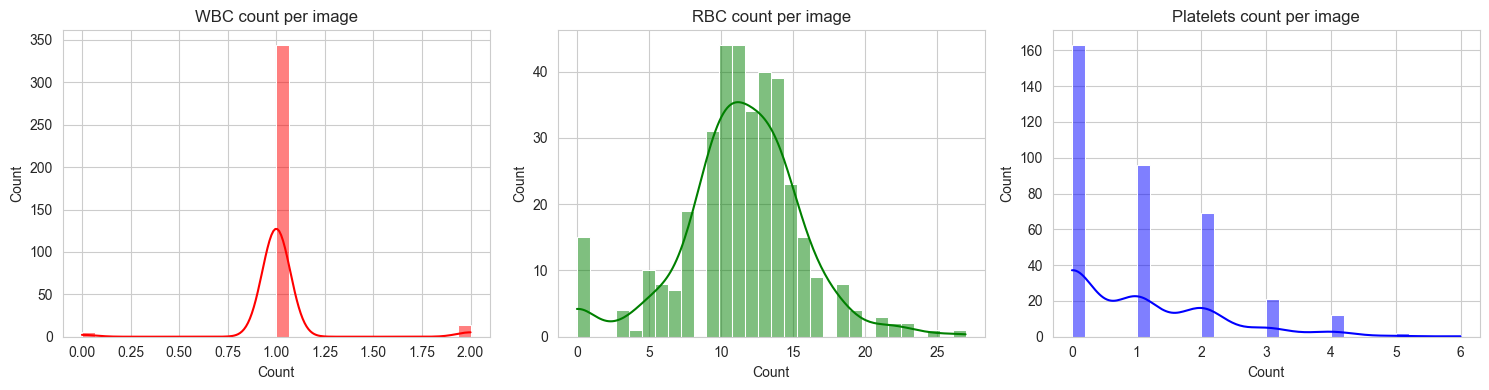

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, cls in enumerate(CLASSES):
    sns.histplot(df[cls], bins=30, kde=True, ax=axes[i], color=CLASS_COLORS[cls])
    axes[i].set_title(f'{cls} count per image')
    axes[i].set_xlabel('Count')
plt.tight_layout()
plt.show()

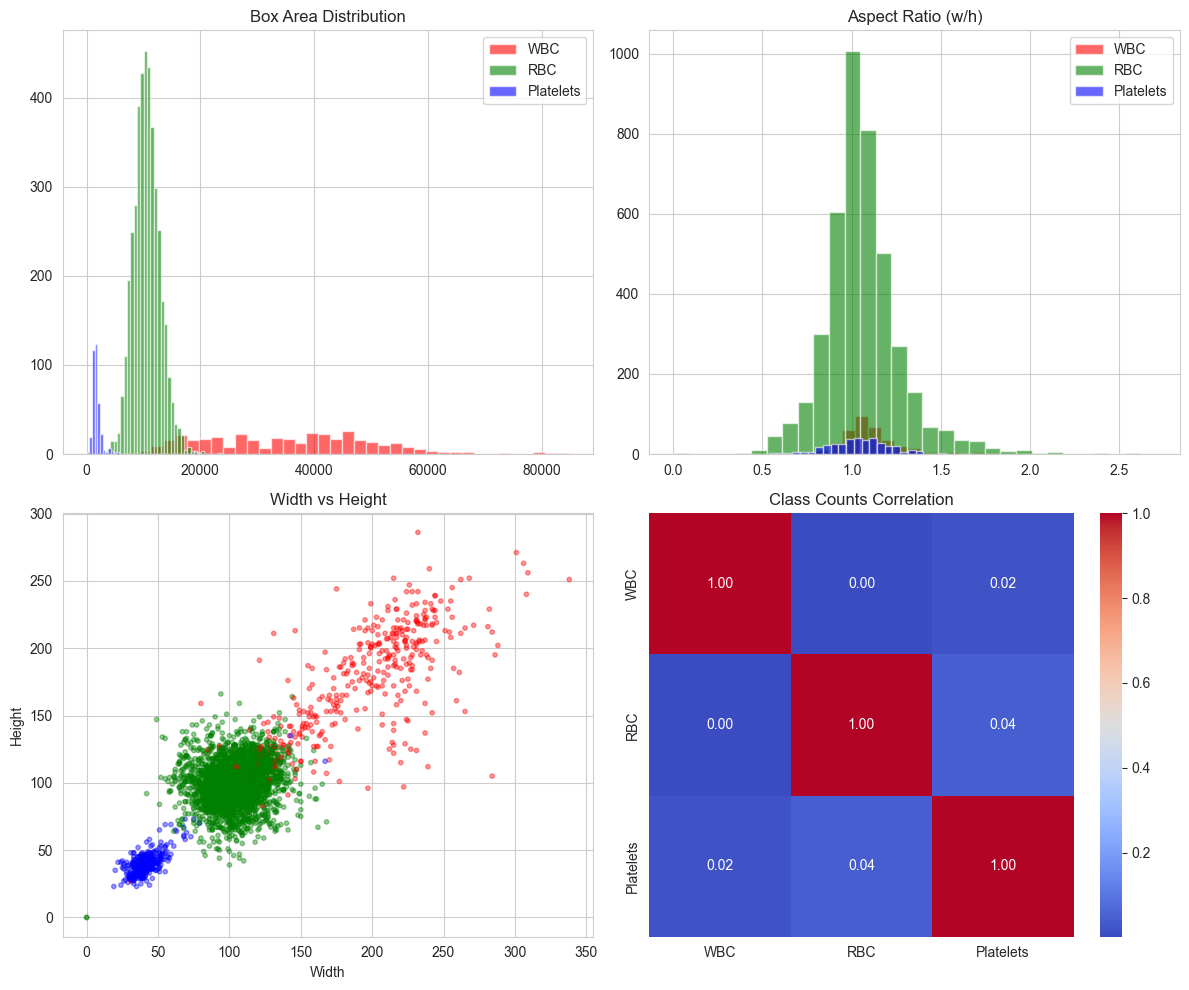

In [5]:
boxes_flat = []
for _, row in df.iterrows():
    for b in row['boxes']:
        boxes_flat.append({'class': b['class'], 'w': b['w'], 'h': b['h'], 'area': b['area']})
boxes_df = pd.DataFrame(boxes_flat)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for cls in CLASSES:
    axes[0,0].hist(boxes_df.loc[boxes_df['class']==cls, 'area'], bins=40, alpha=0.6, label=cls, color=CLASS_COLORS[cls])
axes[0,0].set_title('Box Area Distribution'); axes[0,0].legend()
for cls in CLASSES:
    axes[0,1].hist(boxes_df.loc[boxes_df['class']==cls, 'w']/(boxes_df.loc[boxes_df['class']==cls, 'h']+1e-3), bins=30, alpha=0.6, label=cls, color=CLASS_COLORS[cls])
axes[0,1].set_title('Aspect Ratio (w/h)'); axes[0,1].legend()
axes[1,0].scatter(boxes_df['w'], boxes_df['h'], c=[CLASS_COLORS[c] for c in boxes_df['class']], alpha=0.4, s=10)
axes[1,0].set_title('Width vs Height'); axes[1,0].set_xlabel('Width'); axes[1,0].set_ylabel('Height')
sns.heatmap(df[CLASSES].corr(), annot=True, cmap='coolwarm', ax=axes[1,1], fmt='.2f')
axes[1,1].set_title('Class Counts Correlation')
plt.tight_layout()
plt.show()

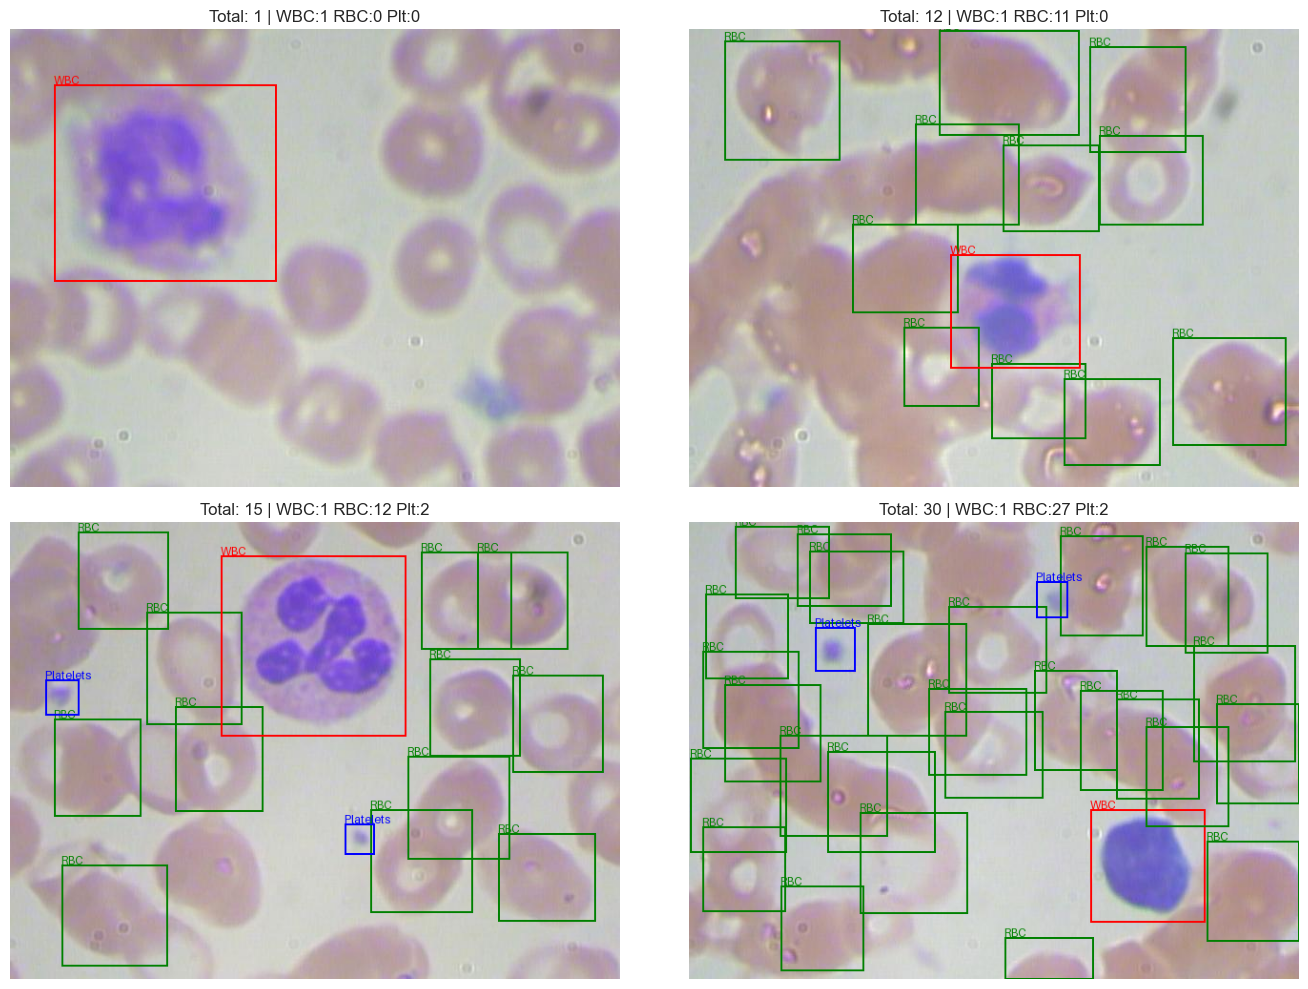

In [6]:
def draw_img_with_boxes(path, boxes, max_show=50):
    img = Image.open(path).convert('RGB')
    draw = ImageDraw.Draw(img)
    for b in boxes[:max_show]:
        col = CLASS_COLORS.get(b['class'], 'yellow')
        draw.rectangle([b['x1'], b['y1'], b['x2'], b['y2']], outline=col, width=2)
        draw.text((b['x1'], b['y1']-12), b['class'], fill=col, font_size=12)
    return img

samples = df.sort_values('total').iloc[[0, len(df)//3, len(df)//3*2, len(df)-1]]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    ax.imshow(draw_img_with_boxes(row['path'], row['boxes']))
    ax.set_title(f"Total: {row['total']} | WBC:{row['WBC']} RBC:{row['RBC']} Plt:{row['Platelets']}")
    ax.axis('off')
plt.tight_layout()
plt.show()